# 1) Chargement des données

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "/content/billets.csv"

if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")
    print("✅ Données chargées :", df.shape)
    display(df)
except Exception as e:
    print("❌ Erreur lors du chargement :", e)


✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54
...,...,...,...,...,...,...,...
1495,False,171.75,104.38,104.17,4.42,3.09,111.28
1496,False,172.19,104.63,104.44,5.27,3.37,110.97
1497,False,171.80,104.01,104.12,5.51,3.36,111.95
1498,False,172.06,104.28,104.06,5.17,3.46,112.25


# 2) Analyse exploratoire (EDA)


In [2]:
#Caractéristiques du dataframe
df.info()
print("\n")
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB




,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN
top,True,NaN,NaN,NaN,NaN,NaN,NaN
freq,1000,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,NaN,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,NaN,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,NaN,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,NaN,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,NaN,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000


In [3]:
#Analyse des NaN
df_clean = df.dropna()
df_nan = df.loc[df.isna().any(axis=1)]
print(df_nan['is_genuine'].value_counts())
print(df_nan['is_genuine'].value_counts(normalize=True) * 100)

is_genuine
True     29
False     8
Name: count, dtype: int64
is_genuine
True     78.378378
False    21.621622
Name: proportion, dtype: float64


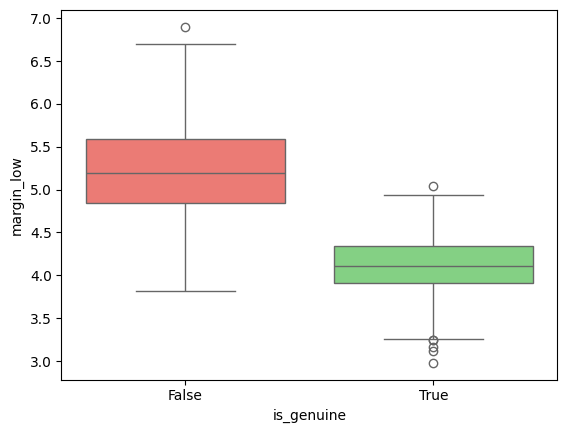

In [4]:
#Analyse de 'margin_low'
palette_billets = {
    True : "#77dd77",
    False : "#ff6961",
}

sns.boxplot(data=df_clean, x=df_clean['is_genuine'], y=df_clean['margin_low'], hue_order=[True, False], palette=palette_billets, hue='is_genuine', legend=False)
plt.show()

In [5]:
#Attribution de la valeur médiane aux 'margin_low' manquants
df_final = df.copy()
df_final['margin_low'] = df_final['margin_low'].fillna(df_final.groupby('is_genuine')['margin_low'].transform('median'))
df_final.info()
print("\n")
df_final.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1500 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB




,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN
top,True,NaN,NaN,NaN,NaN,NaN,NaN
freq,1000,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,171.958440,104.029533,103.920307,4.482453,3.151473,112.67850
std,NaN,0.305195,0.299462,0.325627,0.659650,0.231813,0.87273
min,NaN,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,NaN,171.750000,103.820000,103.710000,4.030000,2.990000,112.03000
50%,NaN,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,NaN,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000


In [6]:
df_final.corr()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
is_genuine,1.000000,0.132756,-0.379833,-0.485092,-0.786067,-0.606262,0.849285
diagonal,0.132756,1.000000,0.019472,-0.024492,-0.110255,-0.055649,0.097587
height_left,-0.379833,0.019472,1.000000,0.242279,0.308449,0.246522,-0.320863
height_right,-0.485092,-0.024492,0.242279,1.000000,0.390699,0.307005,-0.401751
margin_low,-0.786067,-0.110255,0.308449,0.390699,1.000000,0.431210,-0.668552
margin_up,-0.606262,-0.055649,0.246522,0.307005,0.431210,1.000000,-0.520575
length,0.849285,0.097587,-0.320863,-0.401751,-0.668552,-0.520575,1.000000


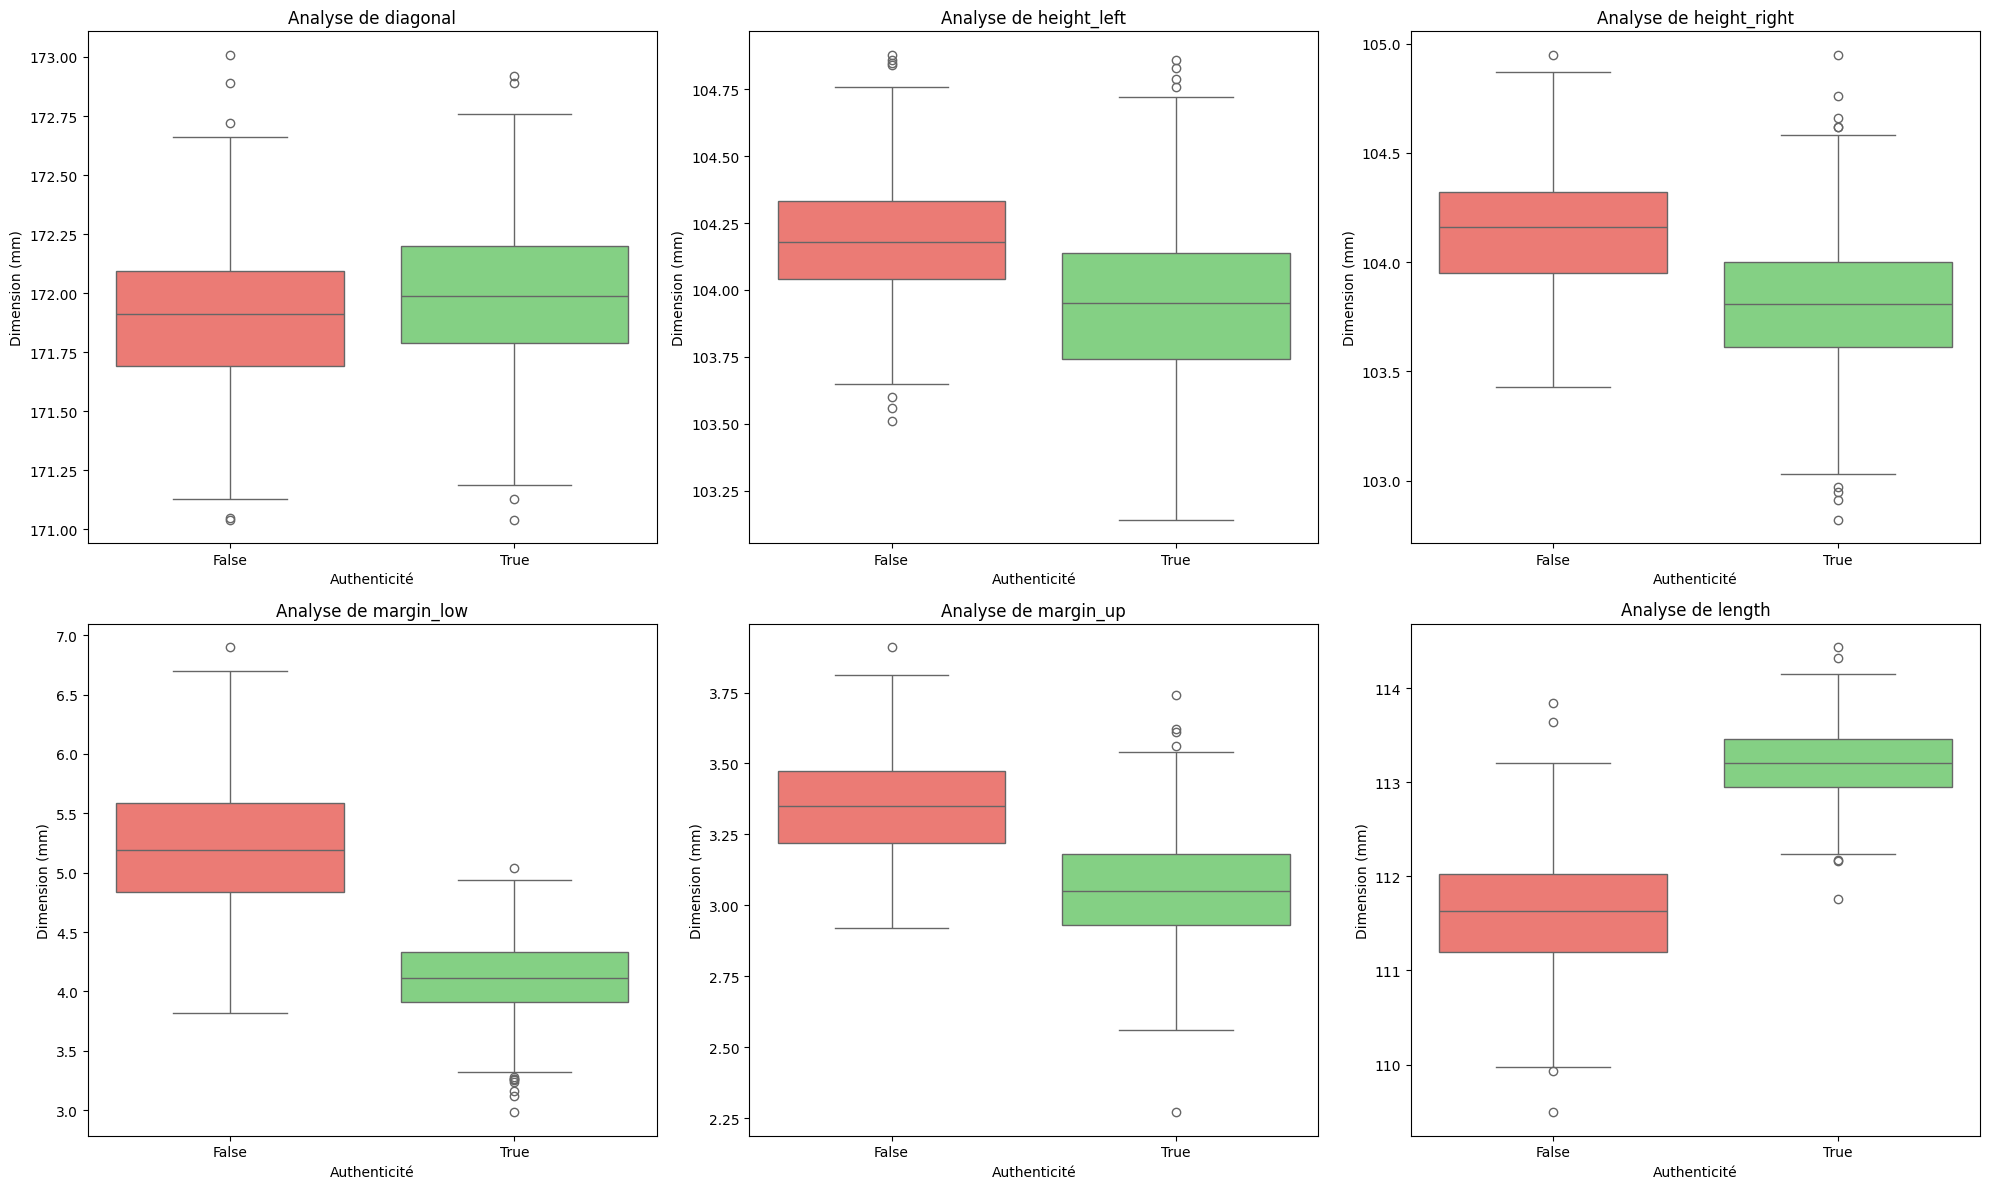

In [7]:
#Analyse des variables prédictives
palette_billets = {
    True : "#77dd77",
    False : "#ff6961",
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

features = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']

for i, col in enumerate(features):
    sns.boxplot(data=df_final, x=df_final['is_genuine'], y=col, ax=axes[i], hue_order=[True, False], palette=palette_billets, hue='is_genuine', legend=False)
    axes[i].set_title(f'Analyse de {col}')
    axes[i].set_xlabel('Authenticité')
    axes[i].set_ylabel('Dimension (mm)')

plt.tight_layout()

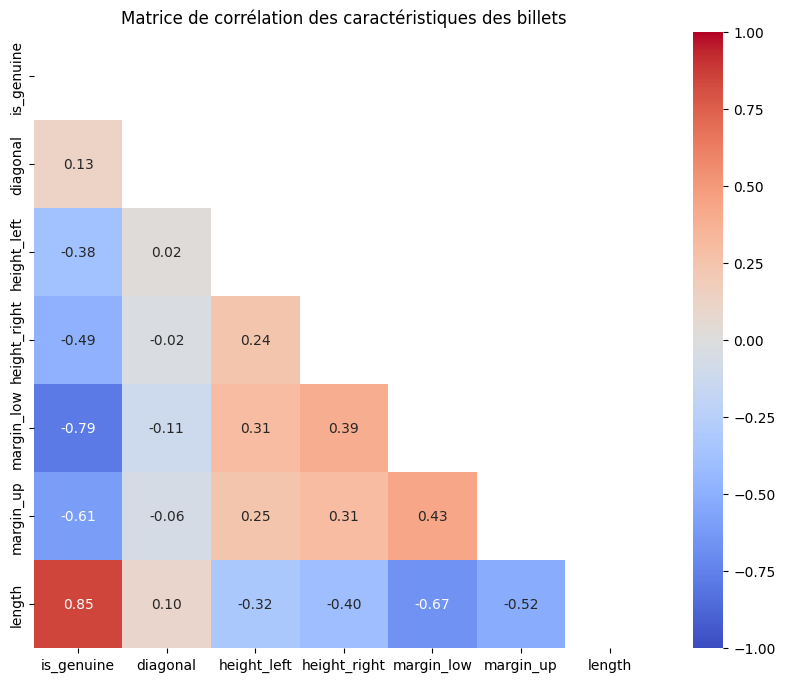

In [8]:
#Corrélation entre la variable cible et les variables predictives
correlation = df_final.corr()

mask = np.triu(np.ones_like(correlation, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matrice de corrélation des caractéristiques des billets')
plt.show()

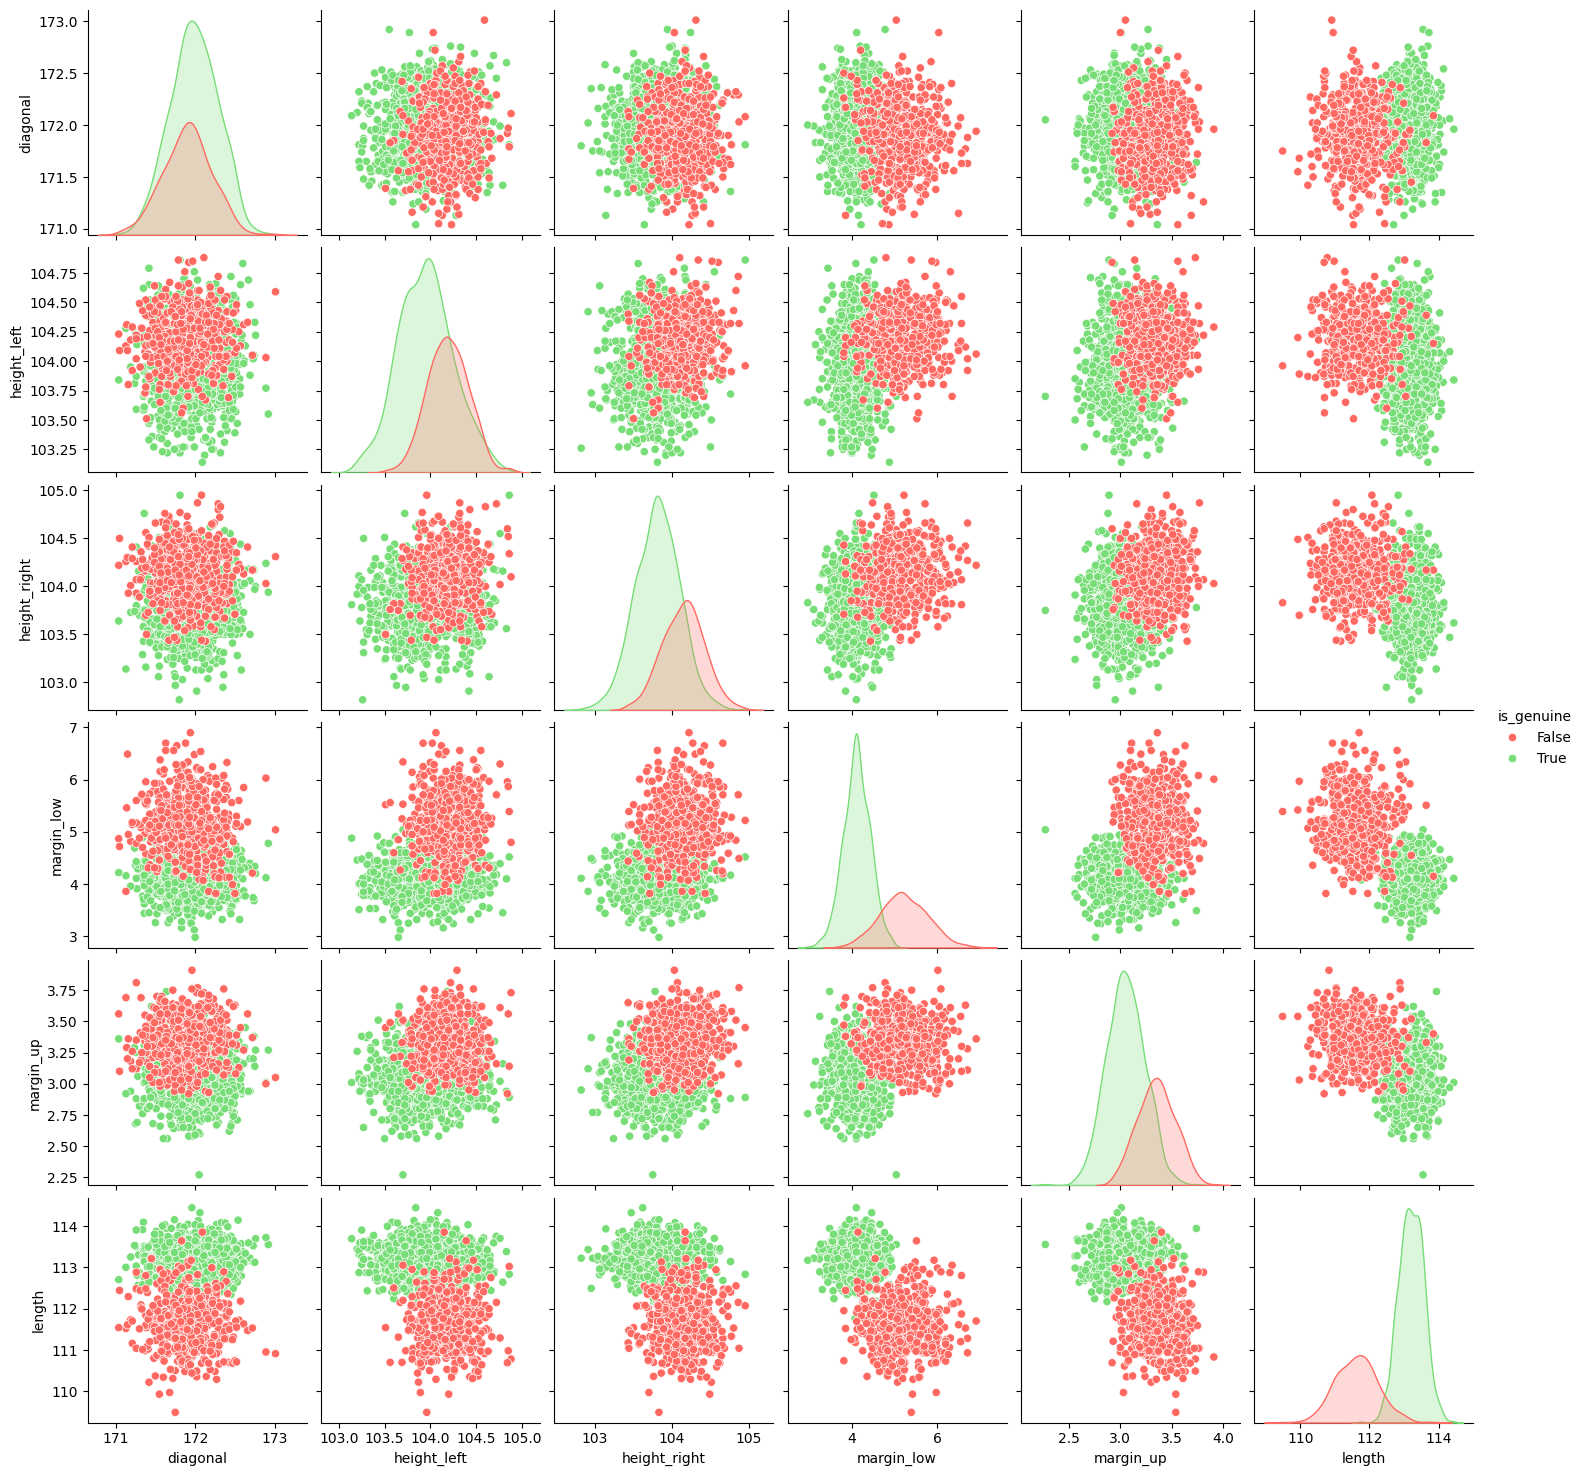

In [9]:
#Pairplot
sns.pairplot(df_final, hue='is_genuine', palette=palette_billets)
plt.show()

Conclusion :

La variable 'diagonal' a une très faible corrélation avec la variable cible (0.13) et un faible pouvoir discriminant, nous la supprimons donc afin de simplifier le modèle.

In [10]:
#Création du dataframe final sans la variable 'diagonal'
df_P12 = df_final.drop(columns=['diagonal'])
df_P12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   height_left   1500 non-null   float64
 2   height_right  1500 non-null   float64
 3   margin_low    1500 non-null   float64
 4   margin_up     1500 non-null   float64
 5   length        1500 non-null   float64
dtypes: bool(1), float64(5)
memory usage: 60.2 KB


# 3) Prétraitement

In [11]:
#Séparation de la variable cible et des variables prédictives
X = df_P12[['height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
y = df_P12['is_genuine']

In [12]:
from sklearn.model_selection import train_test_split

#Création de deux échantillons distincts (entraînement et test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [13]:
from sklearn.preprocessing import StandardScaler

#Mise à l'échelle des variables prédictives
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Vérification données d'entraînement :")
display(pd.DataFrame(X_train).describe().round(2).loc[['mean', 'std']])
print("\nVérification données de test :")
display(pd.DataFrame(X_test).describe().round(2).loc[['mean', 'std']])

Vérification données d'entraînement :


,0,1,2,3,4
mean,-0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0



Vérification données de test :


,0,1,2,3,4
mean,-0.01,0.01,0.08,0.01,-0.07
std,0.97,0.99,1.01,1.00,0.96


# 4) Modélisation

In [14]:
#Importation des librairies
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## K-means

In [15]:
#Comparaison des scores de silouhette
n_components = X_train.shape[1]
scores_silhouette = {}

for k in range(2,n_components+1):
  kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
  kmeans_labels = kmeans.fit_predict(X_test)

  score = silhouette_score(X_test, kmeans_labels)
  scores_silhouette[k] = score
  print(f"Score de silhouette pour {k} clusters : {score:.4f}")

Score de silhouette pour 2 clusters : 0.3895
Score de silhouette pour 3 clusters : 0.2375
Score de silhouette pour 4 clusters : 0.2145
Score de silhouette pour 5 clusters : 0.1749


In [16]:
from sklearn.cluster import KMeans
#Initialisation
kmeans = KMeans(n_clusters=2, random_state=42)

#Assignation
kmeans.fit(X_train)

KMeans(n_clusters=2, random_state=42)

In [17]:
#Prediction pour X_test
y_pred_kmeans = kmeans.predict(X_test)

print(f"Accuracy score : {accuracy_score(y_test, y_pred_kmeans)}")

Accuracy score : 0.9866666666666667


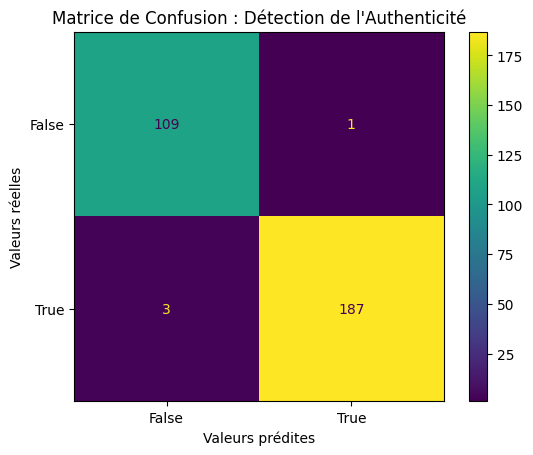

In [18]:
#Matrice de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_kmeans)
plt.title("Matrice de Confusion : Détection de l'Authenticité")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.show()

In [19]:
#Score de précision
print(f"Précision des billets authentiques (True) : {precision_score(y_test, y_pred_kmeans, pos_label=1)}")
print("Recall des billets authentiques (True) :",recall_score(y_test, y_pred_kmeans, pos_label=1))
print("f1-score des faux billets (False) :",f1_score(y_test, y_pred_kmeans, pos_label=1))

Précision des billets authentiques (True) : 0.9946808510638298
Recall des billets authentiques (True) : 0.9842105263157894
f1-score des faux billets (False) : 0.9894179894179894


In [20]:
#Classification report
print(classification_report(y_test, y_pred_kmeans))

              precision    recall  f1-score   support

       False       0.97      0.99      0.98       110
        True       0.99      0.98      0.99       190

    accuracy                           0.99       300
   macro avg       0.98      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



## Régression logistique

In [21]:
#Entraînement avec X_train et y_train
clf = LogisticRegression(random_state=42, max_iter=1000).fit(X_train, y_train)

In [22]:
#Métriques sur les données d'entraînement
print(f"Accuracy score : {accuracy_score(y_train, clf.predict(X_train))}")
print(f"Précision (True) : {precision_score(y_train, clf.predict(X_train), pos_label=1)}")
print("Recall (True) :",recall_score(y_train, clf.predict(X_train), pos_label=1))
print("f1-score (False) :",f1_score(y_train, clf.predict(X_train), pos_label=0))
print("ROC-AUC :", roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1]))

Accuracy score : 0.9925
Précision (True) : 0.9914110429447853
Recall (True) : 0.9975308641975309
f1-score (False) : 0.9883870967741936
ROC-AUC : 0.9988065843621399


In [23]:
#Prédiction pour X_test
y_pred_reg = clf.predict(X_test)

#Accuracy score
print(f"Accuracy score : {accuracy_score(y_test, y_pred_reg)}")

Accuracy score : 0.9933333333333333


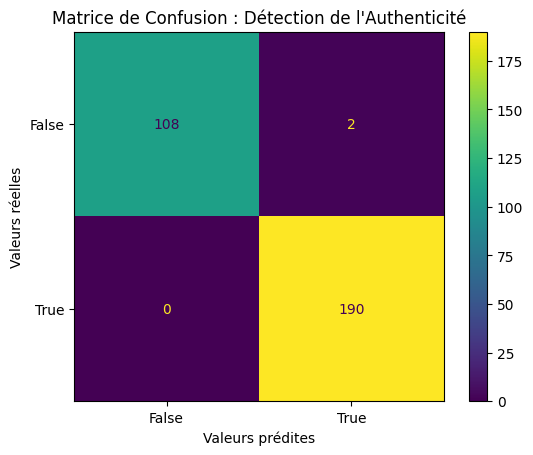

In [24]:
#Matrice de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_reg)
plt.title("Matrice de Confusion : Détection de l'Authenticité")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.show()

In [25]:
#Métriques
print(f"Précision (True) : {precision_score(y_test, y_pred_reg, pos_label=1)}")
print("Recall (True) :",recall_score(y_test, y_pred_reg, pos_label=1))
print("f1-score (Flase) :",f1_score(y_test, y_pred_reg, pos_label=0))
print("ROC-AUC", roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))

Précision (True) : 0.9895833333333334
Recall (True) : 1.0
f1-score (Flase) : 0.9908256880733946
ROC-AUC 0.9998564593301436


In [26]:
#Augmentation du seuil pour minimiser les faux positifs
y_reg_proba=clf.predict_proba(X_test)[:,1]
y_pred_reg_06 = [ 0 if value < 0.6 else 1 for value in y_reg_proba]
y_pred_reg_07 = [ 0 if value < 0.7 else 1 for value in y_reg_proba]
y_pred_reg_08 = [ 0 if value < 0.8 else 1 for value in y_reg_proba]
y_pred_reg_09 = [ 0 if value < 0.9 else 1 for value in y_reg_proba]
print(f"Précision (True) à un seuil de 60% : {precision_score(y_test, y_pred_reg_06, pos_label=1)}")
print(f"Précision (True) à un seuil de 70% : {precision_score(y_test, y_pred_reg_07, pos_label=1)}")
print(f"Précision (True) à un seuil de 80% : {precision_score(y_test, y_pred_reg_08, pos_label=1)}")
print(f"Précision (True) à un seuil de 90% : {precision_score(y_test, y_pred_reg_09, pos_label=1)}")

Précision (True) à un seuil de 60% : 0.9895287958115183
Précision (True) à un seuil de 70% : 0.9947089947089947
Précision (True) à un seuil de 80% : 1.0
Précision (True) à un seuil de 90% : 1.0


In [27]:
#Matrices de confusion pour le seuil à 0.7
confusion_matrix(y_test, y_pred_reg_07)

array([[109,   1],
       [  2, 188]])

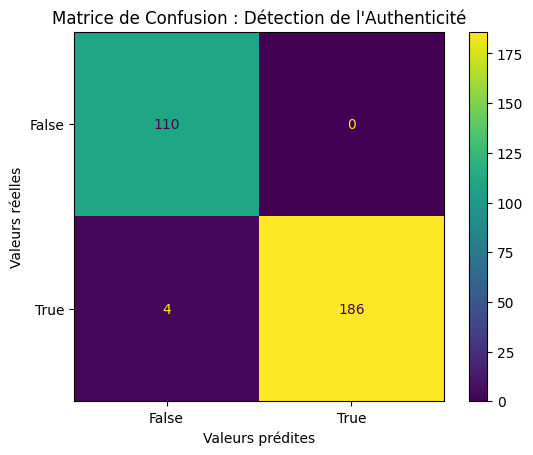

In [28]:
#Matrices de confusion pour le seuil à 0.8
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_reg_08)
plt.title("Matrice de Confusion : Détection de l'Authenticité")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.show()

In [29]:
#Métriques au nouveau seuil 0.8
print(f"Accuracy score : {accuracy_score(y_test, y_pred_reg_08)}")
print(f"Précision (True) : {precision_score(y_test, y_pred_reg_08, pos_label=1)}")
print("Recall (True) :",recall_score(y_test, y_pred_reg_08, pos_label=1))
print("f1-score (False) :",f1_score(y_test, y_pred_reg_08, pos_label=0))
print("ROC-AUC", roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))

Accuracy score : 0.9866666666666667
Précision (True) : 1.0
Recall (True) : 0.9789473684210527
f1-score (False) : 0.9821428571428571
ROC-AUC 0.9998564593301436


In [30]:
#Classification report
print(classification_report(y_test, y_pred_reg_08))

              precision    recall  f1-score   support

       False       0.96      1.00      0.98       110
        True       1.00      0.98      0.99       190

    accuracy                           0.99       300
   macro avg       0.98      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



## KNN

In [31]:
#Recherche de k
param_grid = {'n_neighbors': range(1, 31, 2)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print(f"Meilleur k : {grid.best_params_['n_neighbors']}")

Meilleur k : 13


In [32]:
#Entraînement avec X_train et y_train
knn = KNeighborsClassifier(n_neighbors=13).fit(X_train, y_train)

In [33]:
#Métriques sur les données d'entraînement
print(f"Accuracy score : {accuracy_score(y_train, knn.predict(X_train))}")
print(f"Précision (True) : {precision_score(y_train, knn.predict(X_train), pos_label=1)}")
print("Recall (True) :",recall_score(y_train, knn.predict(X_train), pos_label=1))
print("f1-score (False) :",f1_score(y_train, knn.predict(X_train), pos_label=0))
print("ROC-AUC :", roc_auc_score(y_train, knn.predict_proba(X_train)[:, 1]))

Accuracy score : 0.9916666666666667
Précision (True) : 0.9901960784313726
Recall (True) : 0.9975308641975309
f1-score (False) : 0.9870801033591732
ROC-AUC : 0.9996438746438747


In [34]:
#Prédiction pour X_test
y_pred_knn = knn.predict(X_test)

#Accuracy score
print(f"Accuracy score : {accuracy_score(y_test, y_pred_knn)}")

Accuracy score : 0.9866666666666667


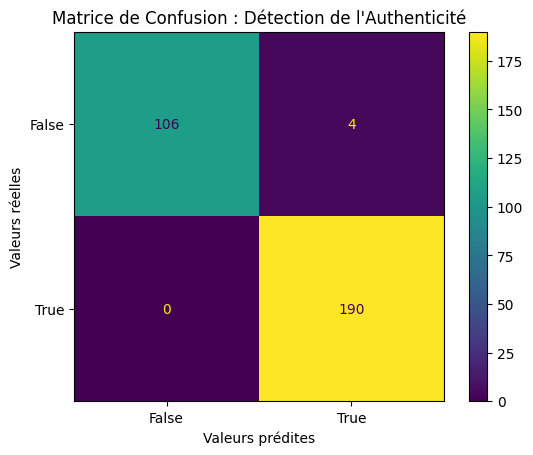

In [35]:
#Matrice de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("Matrice de Confusion : Détection de l'Authenticité")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.show()

In [36]:
#Métriques
print(f"Précision (True) : {precision_score(y_test, y_pred_knn, pos_label=1)}")
print("Recall (True) :",recall_score(y_test, y_pred_knn, pos_label=1))
print("f1-score (False) :",f1_score(y_test, y_pred_knn, pos_label=0))
print("ROC-AUC :", roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1]))

Précision (True) : 0.979381443298969
Recall (True) : 1.0
f1-score (False) : 0.9814814814814815
ROC-AUC : 0.9997846889952153


In [37]:
#Augmentation du seuil pour minimiser les faux positifs
y_knn_proba=knn.predict_proba(X_test)[:,1]
y_pred_knn_06 = [ 0 if value < 0.6 else 1 for value in y_knn_proba]
y_pred_knn_07 = [ 0 if value < 0.7 else 1 for value in y_knn_proba]
y_pred_knn_08 = [ 0 if value < 0.8 else 1 for value in y_knn_proba]
y_pred_knn_09 = [ 0 if value < 0.9 else 1 for value in y_knn_proba]
print(f"Précision (True) à un seuil de 60% : {precision_score(y_test, y_pred_knn_06, pos_label=1)}")
print(f"Précision (True) à un seuil de 70% : {precision_score(y_test, y_pred_knn_07, pos_label=1)}")
print(f"Précision (True) à un seuil de 80% : {precision_score(y_test, y_pred_knn_08, pos_label=1)}")
print(f"Précision (True) à un seuil de 90% : {precision_score(y_test, y_pred_knn_09, pos_label=1)}")

Précision (True) à un seuil de 60% : 0.979381443298969
Précision (True) à un seuil de 70% : 0.9844559585492227
Précision (True) à un seuil de 80% : 0.9895287958115183
Précision (True) à un seuil de 90% : 1.0


In [38]:
#Matrices de confusion pour le seuil à 0.8
confusion_matrix(y_test, y_pred_knn_08)

array([[108,   2],
       [  1, 189]])

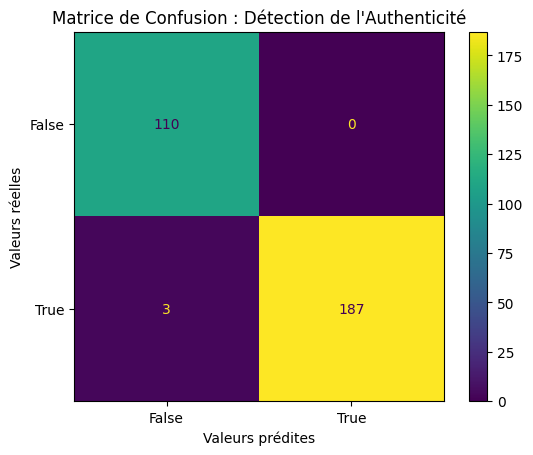

In [39]:
#Matrices de confusion pour le seuil à 0.9
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_09)
plt.title("Matrice de Confusion : Détection de l'Authenticité")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.show()

In [40]:
#Métriques au nouveau seuil 0.7
print(f"Accuracy score : {accuracy_score(y_test, y_pred_knn_09)}")
print(f"Précision (True) : {precision_score(y_test, y_pred_knn_09, pos_label=1)}")
print("Recall (True) :",recall_score(y_test, y_pred_knn_09, pos_label=1))
print("f1-score (False) :",f1_score(y_test, y_pred_knn_09, pos_label=0))
print("ROC-AUC :", roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1]))

Accuracy score : 0.99
Précision (True) : 1.0
Recall (True) : 0.9842105263157894
f1-score (False) : 0.9865470852017937
ROC-AUC : 0.9997846889952153


In [41]:
#Classification report
print(classification_report(y_test, y_pred_knn_09))

              precision    recall  f1-score   support

       False       0.97      1.00      0.99       110
        True       1.00      0.98      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



## Random Forest

In [42]:
#Entraînement avec X_train et y_train
rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)

In [43]:
#Métriques sur les données d'entraînement
print(f"Accuracy score : {accuracy_score(y_train, rf.predict(X_train))}")
print(f"Précision (True) : {precision_score(y_train, rf.predict(X_train), pos_label=1)}")
print("Recall (True) :",recall_score(y_train, rf.predict(X_train), pos_label=1))
print("f1-score (False) :",f1_score(y_train, rf.predict(X_train), pos_label=0))
print("ROC-AUC :", roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1]))

Accuracy score : 1.0
Précision (True) : 1.0
Recall (True) : 1.0
f1-score (False) : 1.0
ROC-AUC : 1.0


In [44]:
#Prédiction pour X_test
y_pred_rf = rf.predict(X_test)

#Accuracy score
print(f"Accuracy score : {accuracy_score(y_test, y_pred_rf)}")

Accuracy score : 0.9933333333333333


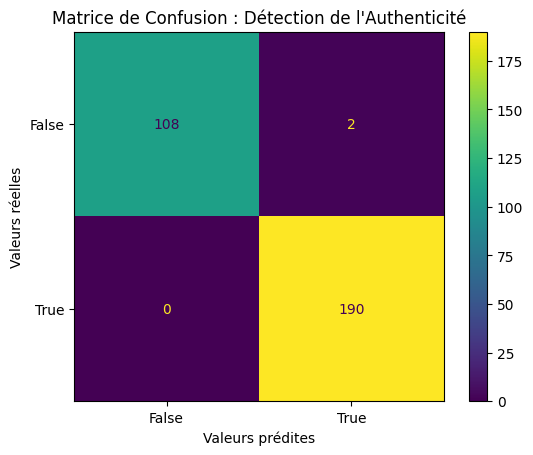

In [45]:
#Matrice de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Matrice de Confusion : Détection de l'Authenticité")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.show()

In [46]:
#Métriques
print(f"Précision (True) : {precision_score(y_test, y_pred_rf, pos_label=1)}")
print("Recall (True) :",recall_score(y_test, y_pred_rf, pos_label=1))
print("f1-score (False) :",f1_score(y_test, y_pred_rf, pos_label=0))
print("ROC-AUC :", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

Précision (True) : 0.9895833333333334
Recall (True) : 1.0
f1-score (False) : 0.9908256880733946
ROC-AUC : 0.9997129186602871


In [47]:
#Augmentation du seuil pour minimiser les faux positifs
y_rf_proba=rf.predict_proba(X_test)[:,1]
y_pred_rf_06 = [ 0 if value < 0.6 else 1 for value in y_rf_proba]
y_pred_rf_07 = [ 0 if value < 0.7 else 1 for value in y_rf_proba]
y_pred_rf_08 = [ 0 if value < 0.8 else 1 for value in y_rf_proba]
y_pred_rf_09 = [ 0 if value < 0.9 else 1 for value in y_rf_proba]
print(f"Précision (True) à un seuil de 60% : {precision_score(y_test, y_pred_rf_06, pos_label=1)}")
print(f"Précision (True) à un seuil de 70% : {precision_score(y_test, y_pred_rf_07, pos_label=1)}")
print(f"Précision (True) à un seuil de 80% : {precision_score(y_test, y_pred_rf_08, pos_label=1)}")
print(f"Précision (True) à un seuil de 90% : {precision_score(y_test, y_pred_rf_09, pos_label=1)}")

Précision (True) à un seuil de 60% : 0.9895287958115183
Précision (True) à un seuil de 70% : 0.9894736842105263
Précision (True) à un seuil de 80% : 1.0
Précision (True) à un seuil de 90% : 1.0


In [48]:
#Matrices de confusion pour le seuil à 0.7
confusion_matrix(y_test, y_pred_rf_07)

array([[108,   2],
       [  2, 188]])

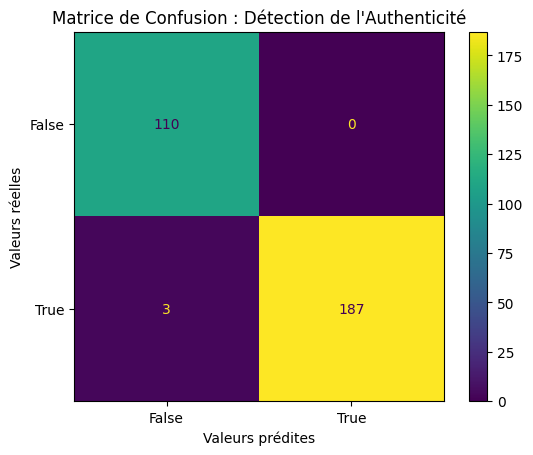

In [49]:
#Matrices de confusion pour le seuil à 0.8
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_08)
plt.title("Matrice de Confusion : Détection de l'Authenticité")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.show()

In [50]:
#Métriques au nouveau seuil 0.8
print(f"Accuracy score : {accuracy_score(y_test, y_pred_rf_08)}")
print(f"Précision (True) : {precision_score(y_test, y_pred_rf_08, pos_label=1)}")
print("Recall (True) :",recall_score(y_test, y_pred_rf_08, pos_label=1))
print("f1-score (False) :",f1_score(y_test, y_pred_rf_08, pos_label=0))
print("ROC-AUC :", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

Accuracy score : 0.99
Précision (True) : 1.0
Recall (True) : 0.9842105263157894
f1-score (False) : 0.9865470852017937
ROC-AUC : 0.9997129186602871


In [51]:
#Classification report
print(classification_report(y_test, y_pred_rf_08))

              precision    recall  f1-score   support

       False       0.97      1.00      0.99       110
        True       1.00      0.98      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [52]:
#Score des variables
feature_importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importance_df

,Feature,Importance
0,height_left,0.016031
1,height_right,0.037016
2,margin_low,0.309911
3,margin_up,0.108055
4,length,0.528987


# Sélection du meilleur modèle

- **K-Means (non supervisé)** :
  - **Précision (True)** : 0.995 #4
  - **Recall (True)** : 0.984 #1
  - **f1-score (False)** : 0.989 #1
  - **Faux positifs (True)** : 1/110 faux billets #4
  - **Faux négatifs (True)** : 3/190 vrais billets #1
  - **Commentaire** :
  Le K-means est un modèle non supervisé ce qui n'a pas beaucoup de sens ici car les étiquettes de classes sont données et il présente un risque non nul de confondre des faux billets avec des vrais.
  Néanmoins, le résultat nous permet de conclure que si nous pouvons scinder l'échantillon en 2 clusters distincts très proches de la réalité à la seule aide des caractéristiques sélectionnées alors ces caractéristiques sont des preuves solides de l'authenticité ou non d'un billet d'euros.

- **Régression Logistique avec seuil à 0.8 (vs 0.5)** :
  - **Accuracy** : 0.987 (0.993) #3
  - **Précision (True)** : 1.000 (0.989) #1
  - **Recall (True)** : 0.979 (1.000) #4
  - **f1-score (False)** : 0.982 (0.991) #4
  - **ROC-AUC** : 0.9998 #1
  - **Faux positifs (True)** : 0/110 faux billets (2) #1
  - **Faux négatifs (True)** : 4/190 vrais billets (0) #4
  - **Commentaire** :
  Le modèle est très performant et l'ajustement du seuil de classification à 0.8 permet d'avoir une précision parfaite sur les faux positifs pour les billets authentiques (sur notre échantillon) ce qui est notre priorité.
  Le compromis est néanmoins impactant vis à vis des faux négatifs pour les billets authentiques bien que le ROC-AUC soit excellent ce qui montre une vraie capacité du modèle à distinguer les deux classes.

- **KNN avec seuil à 0.9 (vs 0.5)** :
  - **Accuracy** : 0.99 (0.987) #1
  - **Précision (True)** : 1.000 (0.979) #1
  - **Recall (True)** : 0.984 (1.000) #1
  - **f1-score (False)** : 0.986 (0.981) #2
  - **ROC-AUC** : 0.9998 #1
  - **Faux positifs (True)** : 0/110 faux billets (4) #1
  - **Faux négatifs (True)** : 3/190 vrais billets (0) #1
  - **Commentaire** :
  Ce modèle est légèrement plus performant que la régression logistique.

- **Random Forest avec seuil à 0.8 (vs 0.5)** :
  - **Accuracy** : 0.99 (0.993) #1
  - **Précision (True)** : 1.000 (0.989) #1
  - **Recall (True)** : 0.984 (1.000) #1
  - **f1-score (False)** : 0.986 (0.991) #2
  - **ROC-AUC** : 0.9997 #3
  - **Faux positifs (True)** : 0/110 faux billets (2) #1
  - **Faux négatifs (True)** : 3/190 vrais billets (0) #1
  - **Commentaire** :
  Ce modèle a d'excellentes performances avec un réajustement à 0.8 du seuil de classification moins strict que pour le KNN (moins de risque que des vrais billets soient pris pour des faux).
  Un ROC-AUC excellent couplé à une précision sur les faux positifs pour les authentiques parfaite, très peu d'erreurs sur le reste et une sensibilité faible au suraprentissage font de ce modèle le candidat idéal pour notre script de détection de faux billets.

# Sauvegarde du meilleur modèle

In [53]:
from sklearn.pipeline import make_pipeline
import joblib

#Ce pipeline inclura son propre StandardScaler qui sera entraîné sur des données brutes
pipeline = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

#Nous allons re-séparer X et y en X_train_raw et y_train_raw spécifiquement pour le fit du pipeline à sauvegarder.
X_train_raw, _, y_train_raw, _ = train_test_split(X, y, test_size=0.20, random_state=42)

#Entraînement du pipeline avec les données brutes d'entraînement
pipeline.fit(X_train_raw, y_train_raw)

#Sauvegarde du pipeline pour la production
joblib.dump(pipeline, 'pipeline.joblib')

['pipeline.joblib']